In [31]:
from torch import optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np 
import random
import torchvision 
import torch.nn.functional as functional

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


In [4]:
!nvidia-smi

Thu Nov 13 16:22:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.88                 Driver Version: 580.88         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060      WDDM  |   00000000:01:00.0  On |                  N/A |
| 34%   34C    P8            N/A  /  115W |    1023MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# Setting uniform seed

In [40]:
torch.manual_seed(32)
torch.cuda.manual_seed(32)
random.seed(42)

In [ ]:
# Set Hyper Parameters

In [75]:
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 3e-4
PATCH_SIZE = 4
NUM_CLASSES=10 # for CIFAR
IMAGE_SIZE = 32
CHANNELS = 3
EMBEDDER_DIM = 256
NUM_HEADS = 8
DEPTH = 6 # Number of Transformer Encoder Blocks
MLP_DIM = 512
DROPOUT_RATE=0.1

In [ ]:
# IMAGE TRANSFORM and dataset prep

In [155]:
cifar10_mean = [0.4914, 0.4822, 0.4465]
cifar10_std = [0.2470, 0.2435, 0.2616]

train_transformer = transforms.Compose([
transforms.RandomCrop(32, padding=4),    
transforms.RandomHorizontalFlip(),    
transforms.ToTensor(),
transforms.Normalize(cifar10_mean, cifar10_std),
    
])

train_dataset = datasets.CIFAR10(root="cifar10_data", train=True, download = True, transform = train_transformer)

In [16]:
train_dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: cifar10_data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.2435, 0.2616])
           )

In [43]:
# Load Testing Data 

test_transformer = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize(cifar10_mean, cifar10_std)
])

test_dataset = datasets.CIFAR10(root="cifar10_data", train=False, download = True, transform = test_transformer)

In [21]:
test_dataset

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: cifar10_data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.2435, 0.2616])
           )

In [156]:
#DataLoaders

dataloader_train = DataLoader(train_dataset, batch_size=128, shuffle=True)
dataloader_test = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"TRAIN DATALOADER : {len(dataloader_train)} batches")
print(f"TEST DATALOADER : {len(dataloader_test)} batches")

TRAIN DATALOADER : 391 batches
TEST DATALOADER : 79 batches


In [137]:
#Patch Embedding , Create patches and return Tensor of Dimansion :  128 X 65 X 128 : 128 images 65 tokens(patches + CLS) per image, 
#128d per token (128d vector per patch)

class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embedding_dim):
        super().__init__()
        self.patch_size = patch_size
       # IMPORTANT : Use Convolution 2d as Projection Layer as its more efficient than a Linear Layer . The paper actually Mentions a Linear Layer . 
       # kernel and stride are assigned to patch size as we want patches and not overlaps  
        self.projection = nn.Conv2d(in_channels = in_channels, out_channels = embedding_dim, kernel_size = patch_size , stride=patch_size)
       # For square images number of patches is (image size/patch size) ^2         
        num_patches = (image_size//patch_size)**2
        #The CLS token (classification token) in Vision Transformers is a special learnable parameter that serves as a placeholder
        #for aggregating global information from all image patches for classification tasks
        self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim)) # Random to begin with 
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embedding_dim))
        #print(self.cls_token)
        #print(self.pos_embed)   
                                      
    def forward(self, tensor: torch.Tensor):
            # Tensor is 128 X 3 X 32 X 32 ( 3 , 32, 32 is the image 32X32 with 3 channels) 
            batch_size = tensor.size(0) # Get Batch Size 
            projected_tensor = self.projection(tensor)  # Each patch becomes 128d feature vector Tensor is now : 128*128*8*8
            flattened_tensor = projected_tensor.flatten(2) # flatten 128*128*8*8 to 128*128*64
            transposed_tensor = flattened_tensor.transpose(1,2) # swap to : 128 *64*128 converts tensor to format (batch_size, sequence_length, embedding_dim) by swapping dims: 
            cls_token = self.cls_token.expand(batch_size, -1, -1) # cls_token is replicated to all 128 images in the batch 
            tensor_with_cls_token = torch.cat((cls_token, transposed_tensor), dim=1)   # CLS Token in position 0 , Position 1 to 64 image patches
            tensor_with_Pos_Embed = tensor_with_cls_token + self.pos_embed 
            return tensor_with_Pos_Embed # 128 X 65 X 128 : 128 images 65 tokens per image ( CLS token + 64 Patches), 128d representation of each token   
    

In [138]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, dropout_rate):
        super().__init__()
        self.fc1 = nn.Linear(in_features=in_features, out_features=hidden_features)
        self.fc2 = nn.Linear(in_features=hidden_features, out_features=in_features)
        self.dropout = nn.Dropout(dropout_rate)
    def forward(self, tensor): # EXPAND ACTIVATE PROJECT BACK , Maintains original Dimensions 
        tensor = self.fc1(tensor)  # Tensor is  128 X 65 X 128 , output is 128 X 65 X 512
        tensor = self.dropout(functional.gelu(tensor)) # Input & output is 128 X 65 X 512 , Activation Function : Gaussian Error Linear Unit
        tensor = self.dropout(self.fc2(tensor)) # input is 128 X 65 X 512 and output is 128 X 65 X 128
        return tensor
        

In [139]:
class TransformerEncoder(nn.Module): 
    def __init__(self, embedding_dim, num_heads, mlp_dim, dropout_rate):
        super().__init__()
        self.norm1 = nn.LayerNorm(embedding_dim) # Mean 0 STD 1 
        # Each head will process embed_dim/num_heads dimensions so embed_dim%num_heads should be 0 . 
        #batch_first=True: Input shape is (batch, seq, features) → (128, 65, 128)
        # Each head processes: 128 / 8 = 16 dimensions for 8 heads
        # Internally reshaped to: (128, 65, 8, 16) (batch seq heads head_dim) ; Output Concatenated Back to 128 X 65 X 128
        self.multiHeadAttn = nn.MultiheadAttention(embed_dim=embedding_dim, num_heads=num_heads, dropout=dropout_rate, batch_first=True)
        self.norm2 = nn.LayerNorm(embedding_dim) # Mean 0 STD 1 
        self.mlp = MLP(embedding_dim, mlp_dim, dropout_rate)

    def forward(self, tensor):
        # q k v for Mutlihead Self Attention come from the same source i.e the normalized tensor 
        attn_output, attn_weights = self.multiHeadAttn(query = self.norm1(tensor), key= self.norm1(tensor), value = self.norm1(tensor)) 
       # print(attn_output.shape)
        tensor = tensor + attn_output # Residual Conenction : Add Original Input to the output from Multi Head Attention 
        return tensor # Shape 128 X 65 X 128 maintained

In [140]:
class VisionTransformer(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, num_classes, embedding_dim, depth, num_heads, mlp_dims, dropout_rate):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, embedding_dim)
        self.encoder = nn.Sequential(
            TransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            TransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            TransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            TransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            TransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            TransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate)
            
        )
        self.norm = nn.LayerNorm(embedding_dim)
        # logits=W⋅x+b , Output is logits of num classes size vector
        self.classification_head = nn.Linear(in_features = embedding_dim, out_features= num_classes) # Linear Classification Head 

    def forward(self, tensor):
        tensor_with_Pos_Embed = self.patch_embed(tensor)
        encoder_output = self.encoder(tensor_with_Pos_Embed)
        normed_encoder_output = self.norm(encoder_output)
        cls_token = normed_encoder_output[:, 0] # Token at position 0 is the CLS TOKEN with Dimension 128 X 128 
        # Coz CLS Token was PREPENDED at position 0 
        return self.classification_head(cls_token) # Output Shape is 128 X 10  ( 10 Classes) 

In [141]:
# Init the Vision transformer Model

model = VisionTransformer(IMAGE_SIZE, PATCH_SIZE,CHANNELS,NUM_CLASSES, EMBEDDER_DIM, DEPTH, NUM_HEADS, MLP_DIM, DROPOUT_RATE ).to(device)

In [142]:
model

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (projection): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): TransformerEncoder(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (multiHeadAttn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=256, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerEncoder(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (multiHeadAttn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  

In [143]:


# Training

def train(model, loader : DataLoader, optimizer, loss_function):
    model.train()
    correct, total_loss = 0, 0  
    for img_batch, labels in loader:
        img_batch = img_batch.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        output = model(img_batch)
        loss = loss_function(output, labels)
        loss.backward() # Back Prop 
        optimizer.step() # gradient Descent
        total_loss+= loss.item() * img_batch.size(0)
        correct+= (output.argmax(1)==labels).sum().item()
    return total_loss/len(loader.dataset) , correct/len(loader.dataset)  

In [149]:
# Evaluation
def evaluate_model(model, loader : DataLoader):
    model.eval()
    correct = 0
    with torch.inference_mode():
        for img_batch, labels in loader:
            img_batch = img_batch.to(device)
            labels = labels.to(device)
            output = model(img_batch)
            predictions = output.argmax(dim=1)
            correct+= (predictions==labels).sum().item()
        return correct/len(loader.dataset)      

In [145]:
from tqdm.auto import tqdm

In [ ]:
train_accuracies, test_accuracies = [], []

# Cross Entropy Loss and Adam Optimizer 
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model.parameters(), lr=LEARNING_RATE)\
EPOCHS=30
for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, dataloader_train, optimizer, loss_function)
    test_acc = evaluate_model(model, dataloader_test)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch : {epoch+1} of {EPOCHS}, Train Loss : {train_loss:.4f} , Train Accuracy : {train_acc:.4f}, Test Accuracy : {test_acc:.4f}")

Epoch : 1 of 10, Train Loss : 1.3394 , Train Accuracy : 0.5322, Test Accuracy : 0.6262
Epoch : 2 of 10, Train Loss : 1.1968 , Train Accuracy : 0.5706, Test Accuracy : 0.6309
Epoch : 3 of 10, Train Loss : 1.1537 , Train Accuracy : 0.5875, Test Accuracy : 0.6341
Epoch : 4 of 10, Train Loss : 1.1247 , Train Accuracy : 0.5981, Test Accuracy : 0.6415
Epoch : 5 of 10, Train Loss : 1.0901 , Train Accuracy : 0.6121, Test Accuracy : 0.6481
Epoch : 6 of 10, Train Loss : 1.0716 , Train Accuracy : 0.6182, Test Accuracy : 0.6499
Epoch : 7 of 10, Train Loss : 1.0424 , Train Accuracy : 0.6290, Test Accuracy : 0.6576


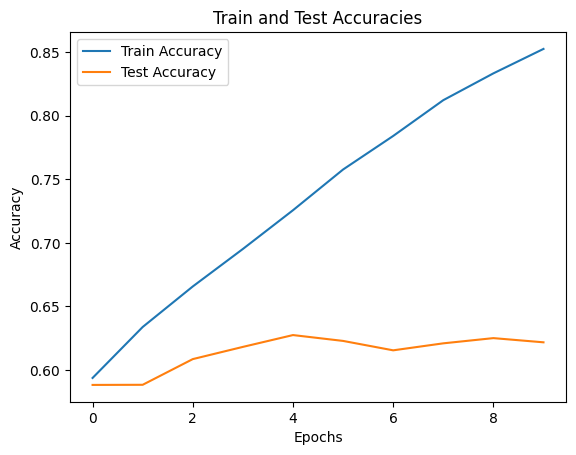

In [154]:
plt.plot(train_accuracies, label = "Train Accuracy")
plt.plot(test_accuracies, label = "Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Train and Test Accuracies")
plt.show()